## Ridge Regression — SVD 

### 1. Problem Setup

Assume we have a dataset  

$$
\{(\mathbf{x}_1, y_1), (\mathbf{x}_2, y_2), \dots, (\mathbf{x}_N, y_N)\}
$$  

where  

$$
\mathbf{x}_i \in \mathbb{R}^D
$$

$$
y_i \in \mathbb{R}
$$

---

### 2. Linear Model

$$
\hat{y} = \mathbf{w}^T \mathbf{x}
$$

$$
\hat{\mathbf{y}} = X \mathbf{w}
$$

---

### 3. Adding Bias Term

$$
X =
\begin{bmatrix}
1 & x_{11} & \cdots & x_{1D} \\
1 & x_{21} & \cdots & x_{2D} \\
\vdots & \vdots & & \vdots \\
1 & x_{N1} & \cdots & x_{ND}
\end{bmatrix}
$$

$$
\mathbf{w} =
\begin{bmatrix}
b \\
w_1 \\
\vdots \\
w_D
\end{bmatrix}
$$

---

### 4. Objective Function

$$
\mathcal{L}(\mathbf{w}) =
\frac{1}{2} \| \mathbf{y} - X \mathbf{w} \|_2^2
+ \frac{\lambda}{2} \| \mathbf{w} \|_2^2
$$

---

### 5. Closed Form Solution

$$
\mathbf{w} =
(X^T X + \lambda I)^{-1} X^T \mathbf{y}
$$

---

### 6. SVD Decomposition

$$
X = U \Sigma V^T
$$

---

### 7. Ridge Solution via SVD

$$
\mathbf{w} = V D U^T \mathbf{y}
$$

$$
D_{ii} = \frac{s_i}{s_i^2 + \lambda}
$$

---

### 8. Bias Handling

$$
D =
\begin{bmatrix}
\frac{1}{s_1} & 0 & \cdots \\
0 & \frac{s_2}{s_2^2 + \lambda} & \cdots \\
\vdots & \vdots & \ddots
\end{bmatrix}
$$

---

### 9. Effect of Regularization

$$
\frac{s_i}{s_i^2 + \lambda}
$$

$$
\lambda \uparrow \Rightarrow \mathbf{w} \rightarrow 0
$$

---

### 10. Prediction

$$
\hat{\mathbf{y}} = X \mathbf{w}
$$

---

### 11. Algorithm Summary

$$
X = U \Sigma V^T
$$

$$
D_{ii} = \frac{s_i}{s_i^2 + \lambda}
$$

$$
\mathbf{w} = V D U^T \mathbf{y}
$$

$$
\hat{\mathbf{y}} = X \mathbf{w}
$$

---

### 12. Final Optimization Perspective

$$
\min_{\mathbf{w}} \;
\| \mathbf{y} - X \mathbf{w} \|_2^2 + \lambda \| \mathbf{w} \|_2^2
$$

In [1]:
class RidgeSVD:
    """
    Ridge Regression using Singular Value Decomposition (SVD).

    This implementation computes the ridge regression solution in a numerically
    stable way using SVD instead of directly inverting (X^T @ X).

    Supports optional bias term handling where the bias is NOT regularized.

    Parameters
    ----------
    lambda_ : float, default=0.01
        Regularization strength. Larger values increase shrinkage of weights.

    add_bias : bool, default=True
        Whether to include an intercept (bias term) in the model.

    Attributes
    ----------
    weights : ndarray of shape (D,) or (D+1,)
        Learned model coefficients (including bias if enabled).
    """

    def __init__(self,lambda_=0.01, add_bias=True):
        self.lambda_ = lambda_
        
        self.add_bias = add_bias

        self.weights = None


    def fit(self,X,y):
        """
        Fit the Ridge Regression model using SVD.

        Steps:
        1. Convert input to numpy arrays
        2. Add bias column if required
        3. Perform SVD decomposition: X = U S V^T
        4. Apply ridge shrinkage on singular values
        5. Compute weights using stable formulation

        Parameters
        ----------
        X : array-like of shape (N, D)
            Training feature matrix.

        y : array-like of shape (N,)
            Target values.

        Returns
        -------
        None
        """

        # Convert inputs to numpy arrays
        X = np.asarray(X)
        y = np.asarray(y)

        y= y.reshape(-1)

        # Ensure X is 2D
        if X.ndim==1:
            X = X.reshape(-1,1)

        N = len(X)

        # Add bias column (intercept term)
        if self.add_bias:
            X = np.hstack((np.ones((N,1)),X))
            
        # Perform Singular Value Decomposition
        # X = U * S * V^T
        U , S , V_transpose = np.linalg.svd(X, full_matrices=False)

        # Compute ridge solution using SVD
        if self.add_bias:
            # Do NOT regularize bias term (first singular value)
            Scaling = np.r_[1/S[0],(S[1:] / (S[1:]**2 + self.lambda_))]
            # Efficient computation using broadcasting
            self.weights = V_transpose.T * Scaling @ (U.T @ y)
        else :

            # Regular ridge shrinkage for all components
            self.weights = (V_transpose.T * (S / (S**2 + self.lambda_))) @ (U.T @ y)

        

    def predict(self,X):
        """
        Predict target values for given input data.

        Parameters
        ----------
        X : array-like of shape (N, D)
            Input feature matrix.

        Returns
        -------
        y_pred : ndarray of shape (N,)
            Predicted values.
        """

        # Convert input to numpy array
        X = np.asarray(X)
        
        # Ensure 2D input
        if X.ndim==1:
            X = X.reshape(-1,1)

        N = len(X)
        
        # Add bias column if model was trained with bias
        if self.add_bias:
            X = np.hstack((np.ones((N,1)),X))

        return X @ self.weights
       

### 1. Objective

See how ridge regression shrinks individual **weights** along different directions when varying the regularization parameter $\lambda$.

---

### 2. Ridge Regression via SVD

Given dataset:

$$
X \in \mathbb{R}^{N \times D}, \quad \mathbf{y} \in \mathbb{R}^N
$$

we compute ridge regression weights using SVD:

$$
X = U \Sigma V^T
$$

and

$$
\mathbf{w}(\lambda) = V \, \text{diag}\Big(\frac{s_i}{s_i^2 + \lambda}\Big) \, U^T \mathbf{y}
$$

---

### 3. Interpretation

- Each weight $w_i$ is **shrinked differently** depending on the singular directions of $X$.  
- Increasing $\lambda$ reduces the magnitude of weights along directions with **low singular values**, while preserving directions with **high variance**.  

---



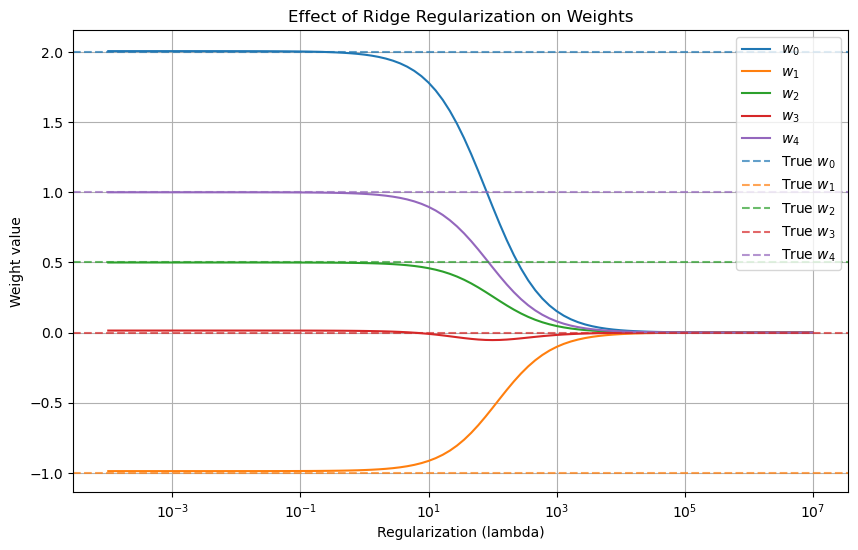

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#  Generate dataset
np.random.seed(42)
N, D = 100, 5
X = np.random.randn(N, D)

true_weights = np.array([2, -1, 0.5, 0, 1])
y = X @ true_weights + 0.1 * np.random.randn(N)

# Range of lambdas
lambdas = np.logspace(-4, 7, 100)
weights_over_lambda = []

# Fit model for each lambda
for lam in lambdas:
    model = RidgeSVD(lambda_=lam, add_bias=False)
    model.fit(X, y)
    weights_over_lambda.append(model.weights)

weights_over_lambda = np.array(weights_over_lambda)



plt.figure(figsize=(10, 6))

# Plot ridge weights over different lambdas
for i in range(weights_over_lambda.shape[1]):
    plt.plot(lambdas, weights_over_lambda[:, i], label=f"$w_{i}$")

# Plot original true weights as horizontal dotted lines
for i, w in enumerate(true_weights):
    plt.axhline(y=w, color=f"C{i}", linestyle='--', alpha=0.7, label=f"True $w_{i}$")

plt.xscale("log")
plt.xlabel("Regularization (lambda)")
plt.ylabel("Weight value")
plt.title("Effect of Ridge Regularization on Weights")
plt.legend()
plt.grid(True)
plt.show()

---

### 4. Observation

- Small $\lambda$: weights are close to **OLS solution**.  
- Large $\lambda$: weights are **shrinked towards zero**.  

---

### 5. Conclusion

Ridge regression performs **direction-wise weight shrinkage**:

$$
\lambda \uparrow \quad \Rightarrow \quad |w_i| \downarrow
$$

This explains **stability improvement**  in ridge regression.

---